<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/w4_perceptron_wt_inputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Perceptron with single input

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1. 데이터 생성 (이미지 조건)
X, y, true_w = make_regression(n_samples=50,
                               n_features=1,
                               noise=15,
                               coef=True,
                               random_state=11)

# 하이퍼파라미터 설정
learning_rate = 0.01
epochs = 20  # SGD는 데이터 하나당 업데이트하므로 에폭을 줄여도 빨리 수렴합니다.

# 가중치(w)와 편향(b) 초기화
w = np.random.randn()
b = np.random.randn()

loss_history = []

# 2. 학습 시작 (SGD 방식)
for epoch in range(epochs):
    epoch_loss = 0

    # 데이터를 하나씩 꺼내어 즉시 업데이트 (Stochastic)
    for i in range(len(X)):
        xi = X[i][0]
        yi = y[i]

        # --- Feedforward ---
        y_pred = xi * w + b

        # 오차 계산
        error = y_pred - yi
        epoch_loss += error ** 2

        # --- Update (SGD 핵심) ---
        # 미분 유도 과정 없이, 오차의 방향과 크기에 따라 즉시 수정
        w = w - learning_rate * (error * xi)
        b = b - learning_rate * error

    loss_history.append(epoch_loss / len(X))

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Loss = {loss_history[-1]:.4f}")

print(f"\n[학습 완료]")
print(f"최종 가중치 w: {w:.4f} (실제값: {true_w:.4f})")
print(f"최종 편향 b: {b:.4f}")

Epoch 0: Loss = 4063.8054
Epoch 2: Loss = 959.9961
Epoch 4: Loss = 388.4185
Epoch 6: Loss = 280.7835
Epoch 8: Loss = 260.4818
Epoch 10: Loss = 256.7634
Epoch 12: Loss = 256.1455
Epoch 14: Loss = 256.0731
Epoch 16: Loss = 256.0802
Epoch 18: Loss = 256.0908

[학습 완료]
최종 가중치 w: 80.5895 (실제값: 80.6567)
최종 편향 b: -0.1780


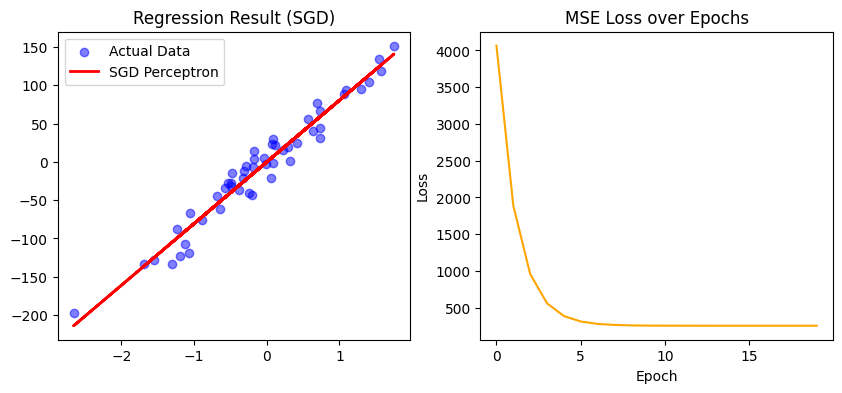

In [12]:
plt.figure(figsize=(10, 4))

# 결과 데이터 플롯
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], y, color='blue', alpha=0.5, label='Actual Data') # Fix: Use only the first feature of X
plt.plot(X[:, 0], X[:, 0]*w + b, color='red', linewidth=2, label='SGD Perceptron') # Fix: Use only the first feature of X for the regression line
plt.title("Regression Result (SGD)")
plt.legend()

# 손실 이력 플롯
plt.subplot(1, 2, 2)
plt.plot(loss_history, color='orange')
plt.title("MSE Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

## 2. Perceptron with multiple inputs

Epoch 0: Loss = 10056.4742
Epoch 2: Loss = 322.0845
Epoch 4: Loss = 106.8088
Epoch 6: Loss = 102.1682
Epoch 8: Loss = 102.1205
Epoch 10: Loss = 102.1298
Epoch 12: Loss = 102.1317
Epoch 14: Loss = 102.1320
Epoch 16: Loss = 102.1321
Epoch 18: Loss = 102.1321
------------------------------
학습된 가중치(w): [69.94602574 93.79412757 97.03407807]
실제 데이터 w: [70.06614038 93.99892217 96.05936691]
학습된 편향(b): -0.1426


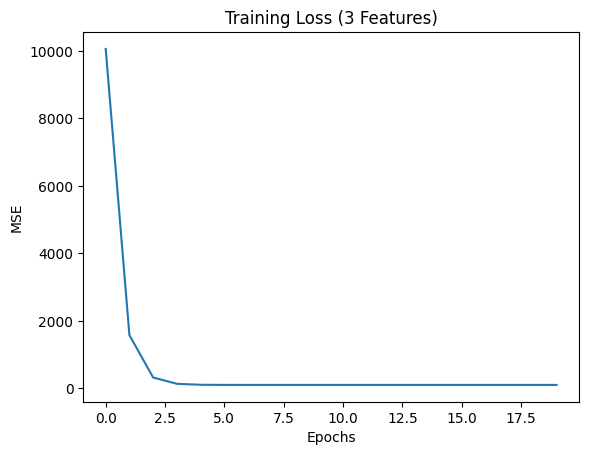

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1. 데이터 생성 (n_features=3)
X, y, true_coef = make_regression(n_samples=100,
                                  n_features=3,
                                  noise=10,
                                  coef=True,
                                  random_state=11)

# 하이퍼파라미터 설정
learning_rate = 0.01
epochs = 20

# 2. 모델 파라미터 초기화
# 입력 변수가 3개이므로 w는 크기가 3인 벡터
w = np.random.randn(3)
b = np.random.randn()

loss_history = []

# 3. 학습 (Stochastic Gradient Descent)
for epoch in range(epochs):
    epoch_loss = 0

    for i in range(len(X)):
        xi = X[i]    # 크기가 3인 벡터 [x1, x2, x3]
        yi = y[i]    # 실제값 (Scalar)

        # --- 순전파 (Feedforward) ---
        # y = w1*x1 + w2*x2 + w3*x3 + b 를 np.dot으로 한 번에 계산
        y_pred = np.dot(xi, w) + b

        # 오차 계산
        error = y_pred - yi
        epoch_loss += error ** 2

        # --- 역전파 및 업데이트 (SGD) ---
        # w_new = w_old - η * error * x
        # Numpy의 브로드캐스팅 덕분에 w(3,)와 xi(3,)의 연산이 한 번에 처리됨
        w = w - learning_rate * (error * xi)
        b = b - learning_rate * error

    # 평균 손실 기록
    loss_history.append(epoch_loss / len(X))

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Loss = {loss_history[-1]:.4f}")

# 4. 결과 출력
print("-" * 30)
print(f"학습된 가중치(w): {w}")
print(f"실제 데이터 w: {true_coef}")
print(f"학습된 편향(b): {b:.4f}")

# 5. 손실 그래프 시각화
plt.plot(loss_history)
plt.title("Training Loss (3 Features)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

## single과 multiple input을 가진 Perceptron의 차이

### 1. 가중치($w$)의 정의1개일 때: 가중치가 단 하나이므로 단일 실수값으로 충분합니다.3개일 때: 각 입력($x_1, x_2, x_3$)에 대응하는 가중치($w_1, w_2, w_3$)가 필요하므로 크기가 3인 배열로 정의합니다.

- Feature 1개
w = np.random.randn()    # 예: 0.5

- Feature 3개
w = np.random.randn(3)   # 예: [0.5, -0.2, 0.8]


## 2. 예측값($y_{pred}$) 계산 (순전파)1개일 때: 단순 곱셈을 수행하지만 3개일 때: 입력 벡터와 가중치 벡터의 **내적(Dot Product)** 을 수행합니다.

- Feature 1개
y_pred = xi * w + b

- Feature 3개
y_pred = np.dot(xi, w) + b

In [26]:
print(xi)
print()
print(w)

[ 1.29127473 -0.52308763 -0.25127692]

[69.94602649 93.79412777 97.03407905]


In [27]:
print(np.dot(xi, w))

16.874563166430143


## 3. 가중치($w$) 업데이트 (역전파/SGD)1개일 때: 단일 가중치 $w$ 하나만 수정합니다.3개일 때: Numpy의 브로드캐스팅 기능을 통해 가중치 벡터 3개를 동시에 수정합니다.

- Feature 1개

> w(1개) = w(1개) - 학습률 * (오차 * x(1개))

> w = w - learning_rate * (error * xi)

- Feature 3개

> w(3개) = w(3개) - 학습률 * (오차 * xi(3개 벡터))

> w = w - learning_rate * (error * xi)

- 위 식은 겉보기에 같지만, xi가 배열이므로 w의 요소 3개가 각각 업데이트됩니다.
